---
# Task 2 : Exploratory Data Analysis (EDA)
**Objectif :** Calculer des statistiques descriptives, visualiser les distributions et analyser les corrélations.  
**Dataset :** S&P 500 Stock Prices (497 472 lignes — 505 entreprises — 2014 à 2017)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

print("Librairies importées avec succès")
print(f"   pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

Librairies importées avec succès
   pandas 3.0.1 | numpy 2.4.3 | seaborn 0.13.2


In [4]:
df = pd.read_csv('data/Stock Prices Data Set.csv')

print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head(5)

Dataset chargé : 497472 lignes × 7 colonnes


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [5]:
print("=" * 50)
print("INFORMATIONS GÉNÉRALES")
print("=" * 50)
df.info()

INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 26.6 MB


In [6]:
print("=" * 50)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 50)
df.describe().round(2)

STATISTIQUES DESCRIPTIVES


,open,high,low,close,volume
count,497461.00,497464.00,497464.00,497472.00,4.974720e+05
mean,86.35,87.13,85.55,86.37,4.253611e+06
std,101.47,102.31,100.57,101.47,8.232139e+06
min,1.62,1.69,1.50,1.59,0.000000e+00
25%,41.69,42.09,41.28,41.70,1.080166e+06
50%,64.97,65.56,64.35,64.98,2.084896e+06
75%,98.41,99.23,97.58,98.42,4.271928e+06
max,2044.00,2067.99,2035.11,2049.00,6.182376e+08


In [7]:
print("=" * 50)
print("VALEURS MANQUANTES")
print("=" * 50)

missing = df.isnull().sum() 
missing_df = pd.DataFrame({'Valeurs manquantes': missing})

print(missing_df)
print(f"\nTotal valeurs manquantes : {missing.sum()}")

VALEURS MANQUANTES
        Valeurs manquantes
symbol                   0
date                     0
open                    11
high                     8
low                      8
close                    0
volume                   0

Total valeurs manquantes : 27


In [8]:
print("=" * 55)
print("🔍 DOUBLONS")
print("=" * 55)

duplicates = df.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

# Vérifier aussi les doublons sur symbol + date (une action ne peut pas
# avoir deux entrées le même jour)
duplicates_key = df.duplicated(subset=['symbol', 'date']).sum()
print(f"Doublons sur symbol + date : {duplicates_key}")

🔍 DOUBLONS
Nombre de doublons : 0
Doublons sur symbol + date : 0


In [16]:
print("=" * 55)
print("TRAITEMENT DES VALEURS MANQUANTES")
print("valeurs imputées par la médiane du symbol correspondant")
print("=" * 55)

df_clean = df.copy()

# Conversion de la date en datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Colonnes avec valeurs manquantes
cols_with_nan = ['open', 'high', 'low']

for col in cols_with_nan:
    n_missing = df_clean[col].isnull().sum()
    
    # Imputation par la médiane par symbol
    df_clean[col] = df_clean.groupby('symbol')[col].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"  '{col}' : {n_missing} ")

print(f"\n Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")
print(f"   Shape finale : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes")

TRAITEMENT DES VALEURS MANQUANTES
valeurs imputées par la médiane du symbol correspondant
  'open' : 11 
  'high' : 8 
  'low' : 8 

 Valeurs manquantes restantes : 0
   Shape finale : 497,472 lignes × 7 colonnes


In [23]:
print("=" * 55)
print("RÉSUMÉ — DATA CLEANING")
print("=" * 55)

summary = pd.DataFrame({
    'Métrique': [
        'Lignes totales',
        'Colonnes',
        'Entreprises (symbols)',
        'Période',
        'Valeurs manquantes traitées',
        'Doublons supprimés',
        'Type date corrigé',
    ],
    'Valeur': [
        f"{df_clean.shape[0]:,}",
        df_clean.shape[1],
        df_clean['symbol'].nunique(),
        f"{df_clean['date'].min().date()} → {df_clean['date'].max().date()}",
        '27 (imputées par médiane par symbol)',
        '0',
        'str → datetime',
    ]
})

print(summary.to_string(index=False))

RÉSUMÉ — DATA CLEANING
                   Métrique                               Valeur
             Lignes totales                              497,472
                   Colonnes                                    7
      Entreprises (symbols)                                  505
                    Période              2014-01-02 → 2017-12-29
Valeurs manquantes traitées 27 (imputées par médiane par symbol)
         Doublons supprimés                                    0
          Type date corrigé                       str → datetime


---
## Analyse Exploratoire (EDA)

In [24]:
print("=" * 55)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 55)

stats = df_clean[['open', 'high', 'low', 'close', 'volume']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

stats.index = ['Moyenne', 'Médiane', 'Écart-type', 'Min', 'Max']
print(stats.to_string())

STATISTIQUES DESCRIPTIVES
               open     high      low    close        volume
Moyenne       86.35    87.13    85.55    86.37  4.253611e+06
Médiane       64.97    65.56    64.35    64.98  2.084896e+06
Écart-type   101.47   102.31   100.57   101.47  8.232139e+06
Min            1.62     1.69     1.50     1.59  0.000000e+00
Max         2044.00  2067.99  2035.11  2049.00  6.182376e+08


In [30]:
print("=" * 55)
print("TOP 10 ACTIONS LES PLUS CHÈRES (prix moyen close)")
print("=" * 55)

top10 = (df_clean.groupby('symbol')['close']
         .mean()
         .sort_values(ascending=False)
         .head(10)
         .round(2))

print(top10.to_string())

TOP 10 ACTIONS LES PLUS CHÈRES (prix moyen close)
symbol
PCLN     1390.27
GOOGL     722.56
GOOG      714.50
AZO       660.25
AMZN      619.24
CMG       516.85
REGN      412.34
MTD       377.85
BLK       359.97
BIIB      310.47


BAR PLOT — Top 10 actions les plus chères


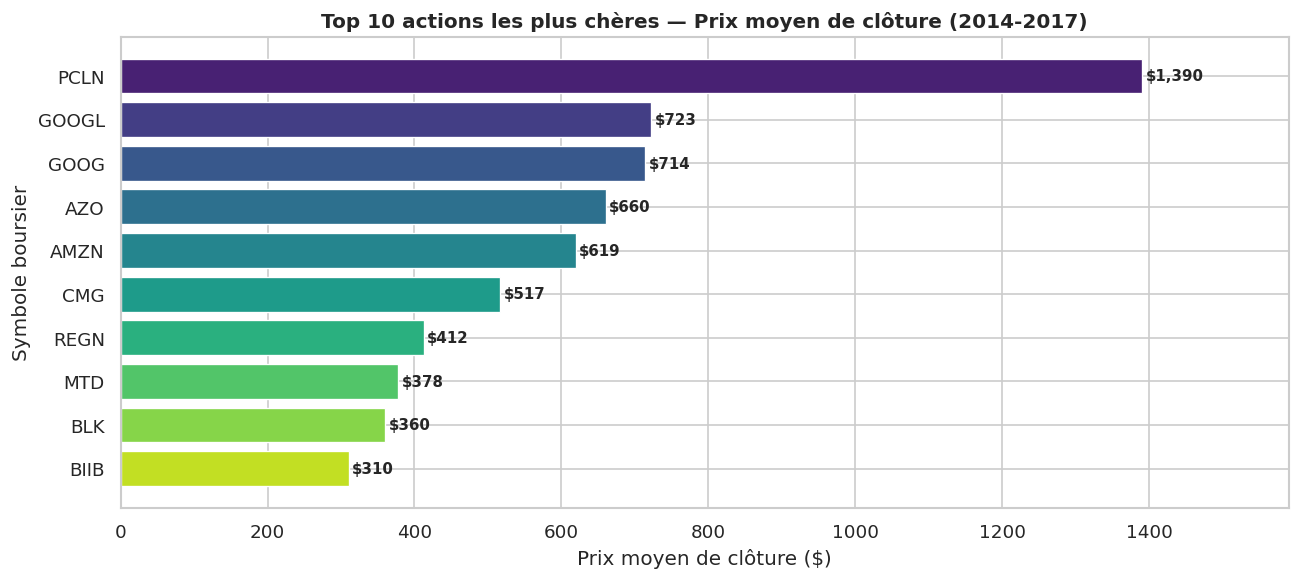

Graphique sauvegardé : outputs/top10_stocks.png


In [36]:
print("=" * 55)
print("BAR PLOT — Top 10 actions les plus chères")
print("=" * 55)

fig, ax = plt.subplots(figsize=(11, 5))

colors = sns.color_palette('viridis', len(top10))
bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.8)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_title("Top 10 actions les plus chères — Prix moyen de clôture (2014-2017)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Prix moyen de clôture ($)")
ax.set_ylabel("Symbole boursier")
ax.set_xlim(0, top10.max() + 200)

plt.tight_layout()
plt.savefig('outputs/top10_stocks.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/top10_stocks.png")

LINE CHART — Évolution du prix de clôture


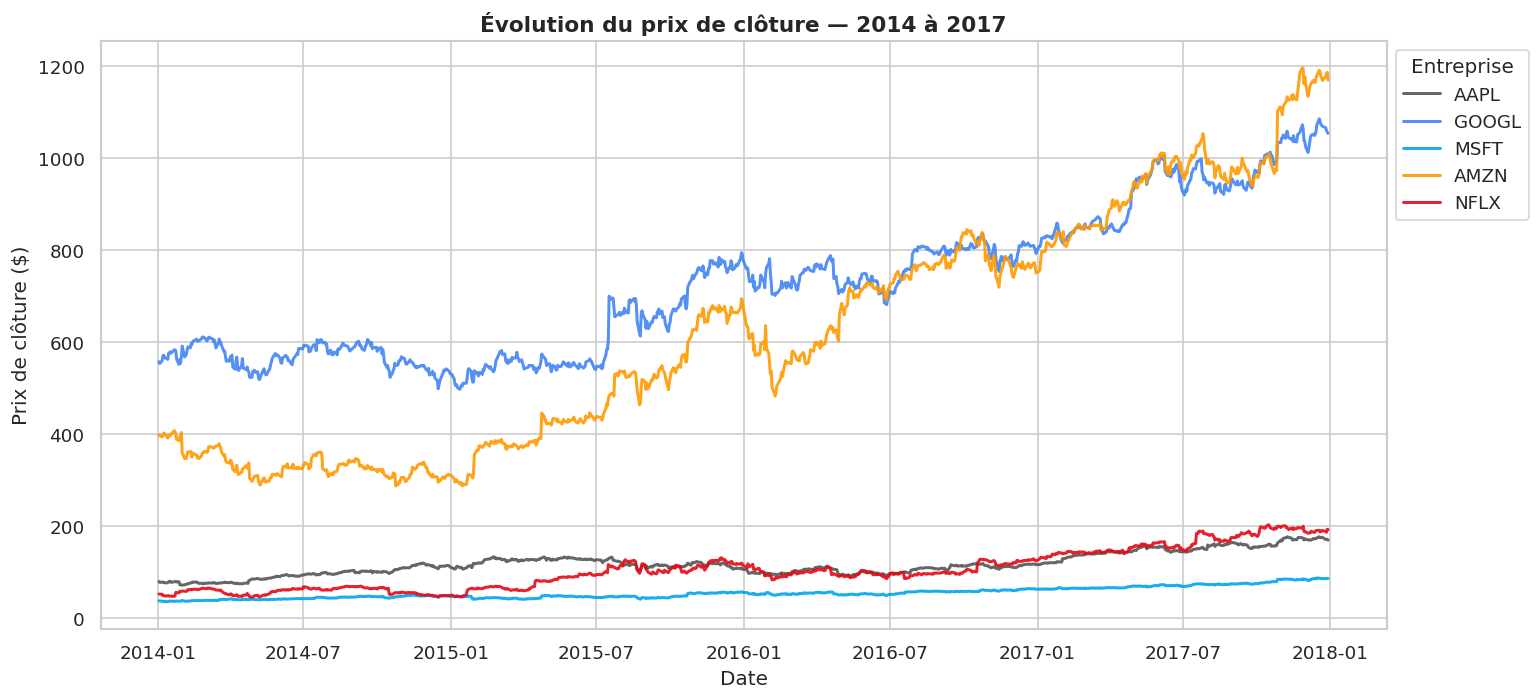

Graphique sauvegardé : outputs/evolution_prix.png


In [37]:
print("=" * 55)
print("LINE CHART — Évolution du prix de clôture")
print("=" * 55)

# Sélection de 5 entreprises emblématiques
symbols = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'NFLX']
df_top = df_clean[df_clean['symbol'].isin(symbols)]

fig, ax = plt.subplots(figsize=(13, 6))

palette_stocks = {
    'AAPL' : '#555555',
    'GOOGL': '#4285F4',
    'MSFT' : '#00A4EF',
    'AMZN' : '#FF9900',
    'NFLX' : '#E50914'
}

for symbol, color in palette_stocks.items():
    data = df_top[df_top['symbol'] == symbol].sort_values('date')
    ax.plot(data['date'], data['close'],
            label=symbol, color=color, linewidth=1.8, alpha=0.9)

ax.set_title("Évolution du prix de clôture — 2014 à 2017",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Prix de clôture ($)")
ax.legend(title="Entreprise", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('outputs/evolution_prix.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/evolution_prix.png")

DISTRIBUTION DES PRIX DE CLÔTURE


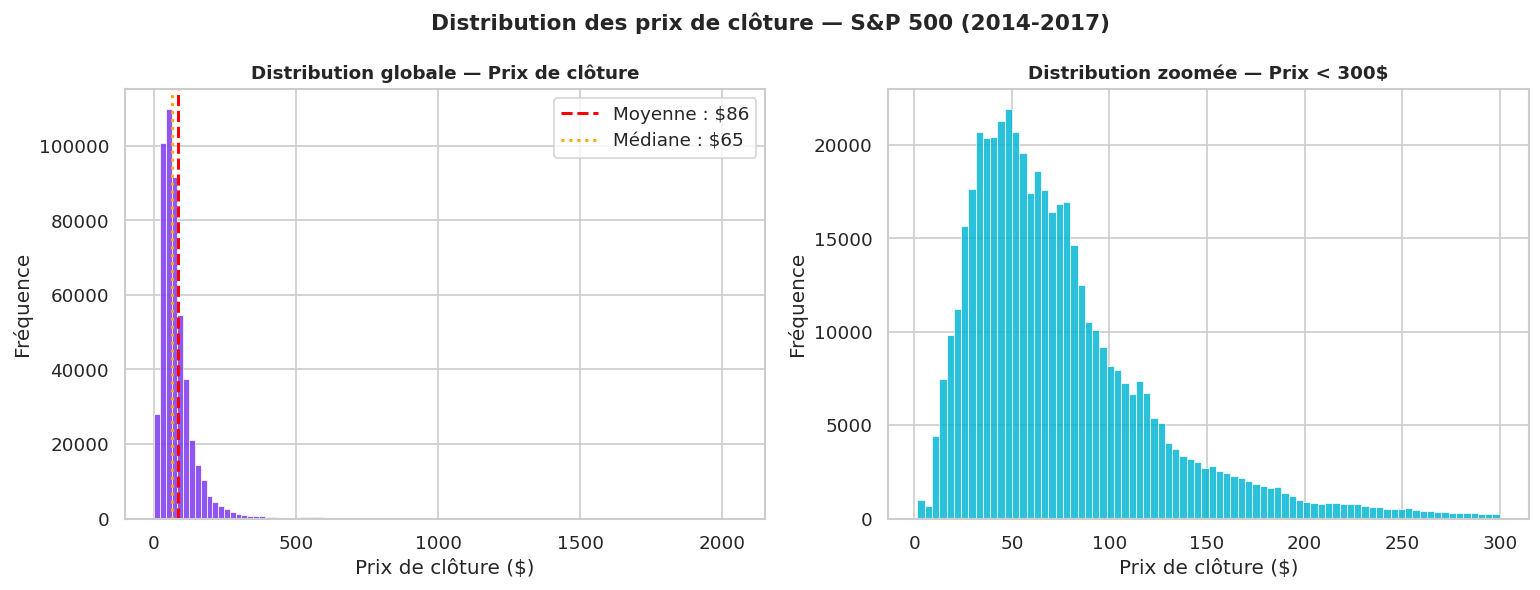

Graphique sauvegardé : outputs/distribution_prix.png


In [39]:
print("=" * 55)
print("DISTRIBUTION DES PRIX DE CLÔTURE")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme global
axes[0].hist(df_clean['close'], bins=100,
             color='#7C3AED', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[0].set_title("Distribution globale — Prix de clôture", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Prix de clôture ($)")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(df_clean['close'].mean(),
                color='red', linestyle='--', linewidth=1.8,
                label=f"Moyenne : ${df_clean['close'].mean():.0f}")
axes[0].axvline(df_clean['close'].median(),
                color='orange', linestyle=':', linewidth=1.8,
                label=f"Médiane : ${df_clean['close'].median():.0f}")
axes[0].legend()

# Histogramme zoomé (prix < 300$)
df_zoom = df_clean[df_clean['close'] < 300]
axes[1].hist(df_zoom['close'], bins=80,
             color='#06B6D4', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].set_title("Distribution zoomée — Prix < 300$", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Prix de clôture ($)")
axes[1].set_ylabel("Fréquence")

plt.suptitle("Distribution des prix de clôture — S&P 500 (2014-2017)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/distribution_prix.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/distribution_prix.png")

MATRICE DE CORRÉLATION


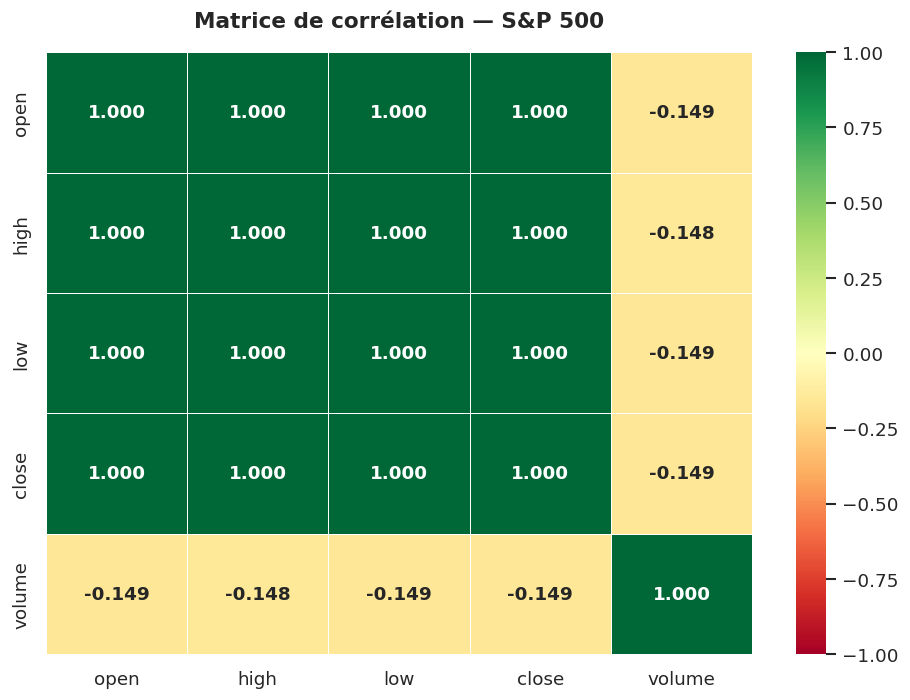

Graphique sauvegardé : outputs/correlation_stocks.png


In [40]:
print("=" * 55)
print("MATRICE DE CORRÉLATION")
print("=" * 55)

corr = df_clean[['open', 'high', 'low', 'close', 'volume']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr,
            annot=True, fmt='.3f',
            cmap='RdYlGn',
            linewidths=0.5,
            center=0, vmin=-1, vmax=1,
            annot_kws={'size': 11, 'fontweight': 'bold'},
            ax=ax)

ax.set_title("Matrice de corrélation — S&P 500", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/correlation_stocks.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/correlation_stocks.png")

BOXPLOT — Volume de transactions par année


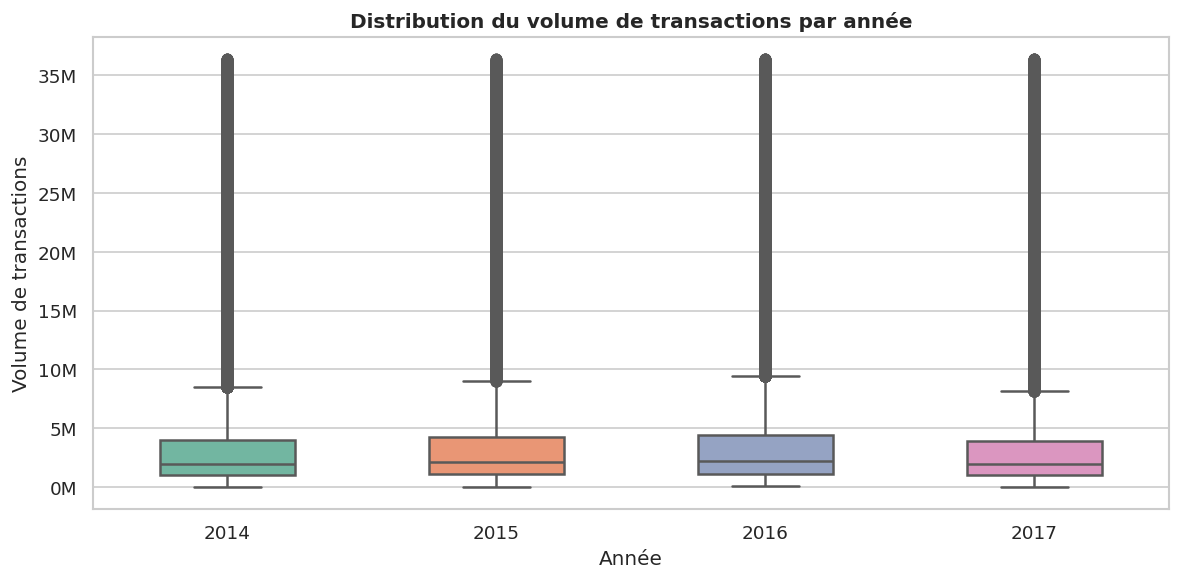

Graphique sauvegardé : outputs/boxplot_volume.png


In [41]:
print("=" * 55)
print("BOXPLOT — Volume de transactions par année")
print("=" * 55)

# Extraire l'année
df_clean['year'] = df_clean['date'].dt.year

# Filtrer le volume > 0 et < 99ème percentile pour enlever les outliers extrêmes
p99 = df_clean['volume'].quantile(0.99)
df_vol = df_clean[df_clean['volume'] > 0]
df_vol = df_vol[df_vol['volume'] < p99]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df_vol, x='year', y='volume',
            palette='Set2', ax=ax,
            width=0.5, linewidth=1.5)

ax.set_title("Distribution du volume de transactions par année",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Année")
ax.set_ylabel("Volume de transactions")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

plt.tight_layout()
plt.savefig('outputs/boxplot_volume.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/boxplot_volume.png")

In [42]:
print("=" * 55)
print("RÉSUMÉ — EDA STOCK PRICES")
print("=" * 55)

resume = pd.DataFrame({
    'Métrique': [
        'Lignes analysées',
        'Entreprises',
        'Période',
        'Prix moyen de clôture',
        'Prix médian de clôture',
        'Action la plus chère (moy.)',
        'Volume médian',
        'Corrélation open/close'
    ],
    'Valeur': [
        f"{df_clean.shape[0]:,}",
        f"{df_clean['symbol'].nunique()}",
        f"{df_clean['date'].min().date()} → {df_clean['date'].max().date()}",
        f"${df_clean['close'].mean():.2f}",
        f"${df_clean['close'].median():.2f}",
        f"PCLN — ${top10.iloc[0]:,.2f}",
        f"{df_clean['volume'].median()/1e6:.2f}M",
        f"{df_clean['open'].corr(df_clean['close']):.3f}"
    ]
})

print(resume.to_string(index=False))

RÉSUMÉ — EDA STOCK PRICES
                   Métrique                  Valeur
           Lignes analysées                 497,472
                Entreprises                     505
                    Période 2014-01-02 → 2017-12-29
      Prix moyen de clôture                  $86.37
     Prix médian de clôture                  $64.98
Action la plus chère (moy.)        PCLN — $1,390.27
              Volume médian                   2.08M
     Corrélation open/close                   1.000
